# Análisis predictivo

En esta etapa del proceso **Businness Analytics** del caso de uso de este trabajo sobre una arquitectura Lakehouse, se leen las tablas Delta integradas, reducidas, limpias y transformadas, directamente del lago de datos para entrenar un conjunto de modelos candidatos de Machine Learning para predecir la probabilidad de contestación. Se selecciona el modelo ideal en base al recall de la clase minoritaria **Yes** (caso en que el votante al menos contesta la llamada sin incluirse los casos de número equivocado) buscando minimizar la cantidad de falsos negativos. Se modifica el peso subrepresentado de la clase minoritaria buscando que el modelo se enfoque en mayor medida o preste mayor atención a la clase minoritaria para descubrir patrones de contestación. 

Se postulan los modelos:

- Función sigmoide o regresión logística
- Árbol de decisión
- Ensemble de árboles de decision
- Máquina de soporte vectorial (SVM)
- Clasificador sigmoide basado en redes neuronales (Fully Layer Conected o MLP)

A través de una rejilla de hiperparámetros bien definida y un proceso de entrenamiento y validación para un conjunto aleatorio de combinaciones de valores de hiperparámetros mediante validación cruzada, se busca encontrar el set de hiperparámetros que maximiza el recall de la clase **Yes**. A continuación de cada modelo se mencionan los hiperparámetros usados y la lista de valores a explorar:

....



Notas:
- El script prioriza el recall de la clase `Yes` (label 1.0) como criterio de selección final.
- Se implementa `class weighting` mediante una columna `classWeightCol` para penalizar la clase minoritaria.
- La búsqueda aleatoria sobre una grilla se hace muestreando combinaciones del ParamGrid.

## Modelado de variables:
Absolutamente todos los modelos de Machine Learning explorados requieren que las variables explicativas y objetivo categóricas estén codificadas numéricamente. Según la naturaleza de cada variable categórica (nominal u ordinal) y el tipo de modelo, resulta más apropiado aplicar un método de codificación u otro (por ejemplo, one hot encoding o label encoding). Aunque los modelos de árboles de decisión (y por ende tampoco los ensembles de árboles de decisión) no lo requieran, todas las variables se normalizan según una distribución normal estándar (media 0 y varianza 1) para acelerar el entrenamiento y evitar inferencias de importancia de variables sesgadas o incorrectas por efecto de diferencias de sus escalas originales. En breve se lista cada variable seleccionada y el tipo de codificación empleada y su razón, utilizando la regla que sigue: variables categóricas nominales con baja cardinalidad o moderada deben codificarse a través de **One Hot Encoding**, puesto que usar la segunda opción **Label Encoding** implicaría una codificación inadecuada para los modelos de regresión logística, máquina de soporte vectorial y redes neuronales, que interpretarían una relación de orden y distancia entre categorías inexistente en la realidad. Variables categóricas ordinales, esto es, que guardan una relación de orden y distancia, deben codificarse a través de **Label Encoding** siempre y cuando cada categoría es igualmente distante de las demás. 

- **day_of_the_week**: Variable categórica ordinal y con categorías equidistantes. Se codifica por tanto a través de **Label Encoder**.
- **time_slot**: Variable categórica ordinal y con categorías equidistantes. Se codifica por tanto a través de **Label Encoder**.
- **operator_name**: Variable categórica nominal que debe codificarse a través de **One Hot Encoding**.
- **strategy_dial**: Variable categórica nominal que debe codificarse a través de **One Hot Encoding**.
- **age_range**: Variable categórica ordinal y con categorías equidistantes. Se codifica por tanto a través de **Label Encoder**.
- **city**: Variable categórica nominal que debe codificarse a través de **One Hot Encoding**.
- **candidate_name**: Variable categórica nominal que debe codificarse a través de **One Hot Encoding**.

## Creación de SparkSession con conector de Spark para tablas Delta

Se crea a continuación la SparkSession con conector Delta Lake para leer las tablas Delta directamente desde el lago de datos

In [1]:
# importación de librerias necesarias
import os
from delta import configure_spark_with_delta_pip
from pyspark.sql import SparkSession
import findspark
import sys
from datetime import datetime
import pandas as pd

In [2]:
# Ayuda a Python a encontrar la instalación local de Apache Spark
findspark.init()

In [3]:
# Definición de ruta que tomará Spark donde escribirá cualquier Data Warehouse manejado (con tablas manejadas) y sus metadatos, que se cree en esta SparkSession
os.environ["SPARK_SQL_WAREHOUSE_DIR"] = "C:/tmp/spark-warehouse" # Aunque ciertamente no es obligatorio en este trabajo

In [4]:
import os
local_dir = r"C:\spark_local"
os.makedirs(local_dir, exist_ok=True)   # crear si no existe

In [5]:
# Constructor de SparkSession con Delta y Kafka
builder = (
    SparkSession
     .builder
     .appName("Kafka+DeltaInNotebook")
     # Estas dos líneas habilitan las extensiones Delta Lake
     .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension")
     .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog")
     # Se descarga e incorpora el conector Delta Lake JAR a través de Maven
     .config("spark.jars.packages",
                "io.delta:delta-spark_2.12:3.2.0")
     # Los conectores de Spark para Kafka se han descargado de Maven y guardado localmente. Se leen desde el directorio local. 
     .config("spark.jars",
             r"C:\Users\TPG\Documents\Spark\spark-3.5.3-bin-hadoop3\spark-3.5.3-bin-hadoop3\jars\spark-sql-kafka-0-10_2.12-3.5.3.jar,"
             r"C:\Users\TPG\Documents\Spark\spark-3.5.3-bin-hadoop3\spark-3.5.3-bin-hadoop3\jars\kafka-clients-3.4.1.jar,"
             r"C:\Users\TPG\Documents\Spark\spark-3.5.3-bin-hadoop3\spark-3.5.3-bin-hadoop3\jars\spark-token-provider-kafka-0-10_2.12-3.5.3.jar,"
             r"C:\Users\TPG\Documents\Spark\spark-3.5.3-bin-hadoop3\spark-3.5.3-bin-hadoop3\jars\commons-pool2-2.11.1.jar"
            )
     # Se utiliza RawLocalFileSystem para escrituras locales, de modo que se evite la creación de ficheros CRC acompañando los ficheros parquet con contenido duplicado.
     .config("spark.hadoop.fs.file.impl", "org.apache.hadoop.fs.RawLocalFileSystem")
     .config("spark.local.dir", local_dir)
     .config("spark.sql.shuffle.partitions", "32")
)   

In [6]:
# Creación de SparkSession con Delta y Kafka
print("Creando la SparkSession...")
spark = configure_spark_with_delta_pip(builder).getOrCreate()
print("-"*70)
if spark and not spark.sparkContext._jsc.sc().isStopped():
    creation_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    print(f"SparkSession creada correctamente a las {creation_time}")
    print(f"Versión de Spark: {spark.version}")
    print(f"Master: {spark.sparkContext.master}")
else:
    print("No se pudo crear la SparkSession o el SparkContext está detenido.")

Creando la SparkSession...
----------------------------------------------------------------------
SparkSession creada correctamente a las 2025-08-30 16:32:27
Versión de Spark: 3.5.3
Master: local[*]


In [7]:
# Si ya tienes spark instanciado, puedes intentar:
''''
import os, tempfile
_custom_tmp = os.path.join(tempfile.gettempdir(), "pyspark_tmp_for_session")
os.makedirs(_custom_tmp, exist_ok=True)
os.environ['TMP'] = _custom_tmp
os.environ['TEMP'] = _custom_tmp
os.environ['TMPDIR'] = _custom_tmp
# try also setting spark.conf (if allowed)
try:
    spark.conf.set("spark.local.dir", _custom_tmp)
except Exception:
    pass
print("Temp dir set to:", _custom_tmp)
'''

'\'\nimport os, tempfile\n_custom_tmp = os.path.join(tempfile.gettempdir(), "pyspark_tmp_for_session")\nos.makedirs(_custom_tmp, exist_ok=True)\nos.environ[\'TMP\'] = _custom_tmp\nos.environ[\'TEMP\'] = _custom_tmp\nos.environ[\'TMPDIR\'] = _custom_tmp\n# try also setting spark.conf (if allowed)\ntry:\n    spark.conf.set("spark.local.dir", _custom_tmp)\nexcept Exception:\n    pass\nprint("Temp dir set to:", _custom_tmp)\n'

In [8]:
print("spark.local.dir:", spark.conf.get("spark.local.dir"))
print("spark.sql.shuffle.partitions:", spark.conf.get("spark.sql.shuffle.partitions"))

spark.local.dir: C:\spark_local
spark.sql.shuffle.partitions: 32


## Entrenamiento de modelos

Se desarrolla un Script de PySpark para lectura de tablas Delta, unión, preprocesamiento, búsqueda aleatoria de hiperparámetroscon validación cruzada (5 folds) y selección final del modelo que maximice el recall de la clase minoritaria (converted = Yes). En específico, de cada set de hiperparámetros seleccionado en una búsqueda aleatoria se calcula el área bajo la curva escogiéndose el modelo con la mejor métrica. El mejor modelo se utiliza para predecir sobre los registros de validación, la probabilidad de contestación y el recall de la clase minoritaria converted = Yes. El proceso se repite por modelo y se da como ganador aquel que presemtó el máximo recall en la clase mencionada. El modelo gaandor se evalua a través del conjunto de test determinándose la matriz de confusión y el reporte de clasificación.

In [9]:
# Importación de librerias necesarias para entrenamiento de modelos
import random
from pyspark.sql.functions import when, col
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, RandomForestClassifier, LinearSVC, MultilayerPerceptronClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from itertools import product
import traceback
import matplotlib.pyplot as plt
import numpy as np

In [10]:
# -------------------------
# Configuración inicial
# -------------------------
# Rutas Delta
calls_path = r"C:\Users\TPG\Documents\Trabajos UNIR\Semestre II\TFM\Data Call Center All\Silver\Calls"
voters_path = r"C:\Users\TPG\Documents\Trabajos UNIR\Semestre II\TFM\Data Call Center All\Silver\Voters"

# Variables fijas y explicativas
free_vars = ["day_of_the_week", "time_slot", "operator_name", "strategy_dial"] # Correcto
fixed_vars = ["age_range", "city", "candidate_name"] # Correcto
label_col_original = "converted"  # Variable objetivo en las tablas Delta
join_key = "voter_id"

# Columnas que requieren One Hot Encoding
ohe_input_cols = ["operator_name", "strategy_dial", "city", "candidate_name"]

# Columnas que requieren Label Encoding
label_encoding_input_cols = ["day_of_the_week", "time_slot", "age_range"]

# Semillas y fracciones
seed = 42
train_frac = 0.7
val_frac = 0.15
test_frac = 0.15

# Tamaño del muestreo aleatorio dentro de la grilla de hiperparámetros
random_search_samples = 20

In [11]:
# -------------------------
# Obtención de dataset de entrenamiento (Lectura de tablas Delta y unión)
# -------------------------
calls_df = spark.read.format("delta").load(calls_path)
voters_df = spark.read.format("delta").load(voters_path)

# Filtrar calls_df para eliminar registros donde initial_call_status_name es "Wrong Number"
calls_df = calls_df.filter(col("initial_call_status_name") != "Wrong Number")

# Generar columna "age_range" en voters_df
voters_df = voters_df.withColumn(
    "age_range",
    when((col("age") > 17) & (col("age") <= 34), "YoungAdult")
    .when((col("age") > 34) & (col("age") <= 54), "Adult")
    .when((col("age") > 54) & (col("age") <= 74), "Senior")
    .when((col("age") > 74) & (col("age") <= 120), "Elderly")
    .otherwise(None)   # coincide con pd.cut donde edades fuera del rango dan NaN
)

# Seleccionar sólo columnas relevantes para ahorrar memoria y evitar ruido
calls_sel_cols = [join_key] + free_vars + [label_col_original] + ["candidate_name"]
voters_sel_cols = [join_key] + fixed_vars

calls_sel = calls_df.select(*[c for c in calls_sel_cols if c in calls_df.columns])
voters_sel = voters_df.select(*[c for c in voters_sel_cols if c in voters_df.columns])

# Join para quedarnos con registros que tengan voter_id en ambas tablas
df = calls_sel.join(voters_sel, on=join_key, how='inner')

In [12]:
# -------------------------
# Obtención de datasets de entrenamiento, validación y testeo debidamente codificados y materializados 
# -------------------------

# Se sabe que `converted` toma los valores 'Yes'/'No'. Usaremos StringIndexer para generarla.
# Se configura asignación de etiquetas numéricas según orden alfabético. 
label_indexer = StringIndexer(inputCol=label_col_original, outputCol="label", handleInvalid="keep", stringOrderType="alphabetAsc")

# -------------------------
# Indexado y encoding de variables categóricas
# -------------------------
# Construimos StringIndexers para todas las columnas categóricas (libres + fijas)
cat_cols = free_vars + fixed_vars
indexers = [StringIndexer(inputCol=c, outputCol=c + "_idx", handleInvalid="keep") for c in cat_cols]

# OneHotEncoder únicamente para variables categóricas nominales con cardinalidad baja o moderada
ohe_input_cols_idx = [c + "_idx" for c in ohe_input_cols]
ohe_output_cols = [c + "_ohe" for c in ohe_input_cols]
ohe = OneHotEncoder(inputCols=ohe_input_cols_idx, outputCols=ohe_output_cols, handleInvalid="keep")

# VectorAssembler únicamente para las variables categóricas ordinales codificadas con Label Encoding
idx_input_cols = [c + "_idx" for c in label_encoding_input_cols] 
idx_to_vec = VectorAssembler(inputCols=idx_input_cols, outputCol="cat_ord_vec", handleInvalid="keep")

# Se hace normalización sobre los campos categóricos indexados con Label Encoding y vectorizados
scaler_cat_ord = StandardScaler(inputCol="cat_ord_vec", outputCol="cat_ord_vec_scaled", withMean=False, withStd=True)

# Se emsamblan en un único vector todos los campos
assembler = VectorAssembler(inputCols=["cat_ord_vec_scaled"]+ohe_output_cols, outputCol="features", handleInvalid="keep")

# -------------------------
# Split en train/val/test
# -------------------------
train, val, test = df.randomSplit([train_frac, val_frac, test_frac], seed=seed)

# Limitar el número de registros para depurar el código de entrenamiento
train = train.limit(100)

# Aplicar indexador de label sobre el dataset completo
label_indexer_model = label_indexer.fit(train)
# Verificar que las etiquetas hayan sido asignadas correctamente
print("Labels order:", label_indexer_model.labels)  # Si se obtiene ['No', 'Yes'], se asigna 1 a "Yes" y 0 a "No"

train = label_indexer_model.transform(train)
val = label_indexer_model.transform(val)
test = label_indexer_model.transform(test)

# -------------------------
# Calcular pesos de clase para class weighting
# -------------------------
counts = train.groupBy("label").count().collect()
label_counts = {row['label']: row['count'] for row in counts}

# Si una de las clases no existe en train, prevenir división por cero
n_total = sum(label_counts.values())
num_classes = len(label_counts)

# Fórmula común: weight_for_class = total_count / (num_classes * count_class)
class_weights = {}
for lab, cnt in label_counts.items():
    class_weights[lab] = float(n_total) / (num_classes * cnt) if cnt > 0 else 1.0

# Añadir columna de peso en cada dataset
train = train.withColumn("classWeightCol", when(col("label") == 1.0, class_weights.get(1.0, 1.0)).otherwise(class_weights.get(0.0, 1.0)))
val = val.withColumn("classWeightCol", when(col("label") == 1.0, class_weights.get(1.0, 1.0)).otherwise(class_weights.get(0.0, 1.0)))
test = test.withColumn("classWeightCol", when(col("label") == 1.0, class_weights.get(1.0, 1.0)).otherwise(class_weights.get(0.0, 1.0)))

# -------------------------
# Creación de pipeline de preprocesamiento 
# -------------------------
preprocessing_stages = indexers + [ohe, idx_to_vec, scaler_cat_ord, assembler]

# --------------- prefit preprocessing ---------------
preproc_pipeline = Pipeline(stages=preprocessing_stages)
preproc_model = preproc_pipeline.fit(train)   # se fitea una sola vez

train_pp = preproc_model.transform(train).select("features", "label", "classWeightCol").cache()
val_pp   = preproc_model.transform(val).select("features", "label", "classWeightCol").cache()
test_pp  = preproc_model.transform(test).select("features", "label", "classWeightCol").cache()

# Forzar acción para materializar los tres datasets y puesto que se pidió antes que fueran cacheados, se mantendrán materializados en memoria. 
train_pp.count()
val_pp.count()
test_pp.count()
# ---------------------------------------------------
train_pp.select("label").distinct().show()

Labels order: ['No', 'Yes']
+-----+
|label|
+-----+
|  0.0|
|  1.0|
+-----+



In [13]:
# Función auxiliar: toma un estimador (clasificador) y un diccionario de grilla (param -> list(values))
# construye una muestra aleatoria de ParamMaps para usar en CrossValidator

def sample_param_maps(estimator, grid_dict, n_samples):
    """
    grid_dict: dict donde keys son Param objects (del estimador) y values son listas de valores.
    Retorna una lista de ParamMap (muestreadas aleatoriamente sin reemplazo hasta n_samples)
    """
    # Construir ParamGrid con ParamGridBuilder
    pg_builder = ParamGridBuilder()
    for p, vals in grid_dict.items():
        pg_builder = pg_builder.addGrid(p, vals)
    all_param_maps = pg_builder.build()

    if len(all_param_maps) <= n_samples:
        return all_param_maps
    else:
        return random.sample(all_param_maps, n_samples)


# Evaluador base (se usa areaUnderPR como proxy durante CV; selección final por recall sobre val set)
evaluator_pr = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderPR")

# Creación de función para métrica de recall para clase 1.0 ("Yes"). Se busca minimizar
def compute_recall_minority(pred_df):
    tp = pred_df.filter((col('label') == 1.0) & (col('prediction') == 1.0)).count()
    fn = pred_df.filter((col('label') == 1.0) & (col('prediction') == 0.0)).count()
    denom = tp + fn
    if denom == 0:
        return 0.0
    return float(tp) / denom


import math
import pandas as pd
from collections import defaultdict

# Función de generación de reporte de clasificación y matriz de confusión
def classification_report_and_confusion(pred_df, label_col='label', pred_col='prediction', as_pandas=True):
    """
    Devuelve (report, confusion_matrix)
    - report: dict con métricas por clase y promedios:
        { label: {'precision':..., 'recall':..., 'f1-score':..., 'support': ...}, 
          'accuracy': ..., 'macro avg': {...}, 'weighted avg': {...} }
    - confusion_matrix: pandas.DataFrame (si as_pandas=True) o dict-of-dicts (si as_pandas=False)
    
    Parámetros:
    - pred_df: pyspark.sql.DataFrame que contiene al menos las columnas label_col y pred_col
    - label_col: nombre de la columna con la etiqueta verdadera (default 'label')
    - pred_col: nombre de la columna con la predicción (default 'prediction')
    - as_pandas: si True devuelve confusion matrix como pandas.DataFrame
    """
    # Agregar conteos por (label, prediction)
    agg = pred_df.groupBy(label_col, pred_col).count().collect()
    
    # Recolectar etiquetas únicas
    labels_set = set()
    counts = {}
    total = 0
    for row in agg:
        true = row[label_col]
        pred = row[pred_col]
        cnt = int(row['count'])
        labels_set.add(true)
        labels_set.add(pred)
        counts.setdefault(true, {})[pred] = cnt
        total += cnt
    
    if total == 0:
        raise ValueError("El DataFrame de predicciones está vacío o no tiene filas agregables.")
    
    # Orden consistente de labels
    try:
        # intenta ordenar naturalmente (numérico primero si aplica)
        labels = sorted(labels_set)
    except Exception:
        labels = list(labels_set)

    # Construir matriz de confusión completa (llenar ceros donde falta)
    conf = {true: {pred: counts.get(true, {}).get(pred, 0) for pred in labels} for true in labels}

    # Calcular métricas por clase
    report = {}
    precisions = []
    recalls = []
    f1s = []
    supports = []
    sum_weighted_precision = 0.0
    sum_support = 0

    for lbl in labels:
        tp = conf[lbl].get(lbl, 0)
        # FP: suma sobre todos los verdaderos != lbl de la columna pred=lbl
        fp = sum(conf[tru].get(lbl, 0) for tru in labels if tru != lbl)
        # FN: suma sobre todos los pred != lbl en la fila true=lbl
        fn = sum(conf[lbl].get(pr, 0) for pr in labels if pr != lbl)
        support = tp + fn  # número de verdaderos de esta clase

        prec = (tp / (tp + fp)) if (tp + fp) > 0 else 0.0
        rec = (tp / (tp + fn)) if (tp + fn) > 0 else 0.0
        f1 = (2 * prec * rec / (prec + rec)) if (prec + rec) > 0 else 0.0

        report[lbl] = {
            'precision': float(prec),
            'recall': float(rec),
            'f1-score': float(f1),
            'support': int(support)
        }

        precisions.append(prec)
        recalls.append(rec)
        f1s.append(f1)
        supports.append(support)
        sum_weighted_precision += prec * support
        sum_support += support

    # Exactitud global
    correct = sum(conf[lbl].get(lbl, 0) for lbl in labels)
    accuracy = float(correct) / float(total)

    # Promedios
    macro_precision = float(sum(precisions) / len(precisions)) if len(precisions) > 0 else 0.0
    macro_recall = float(sum(recalls) / len(recalls)) if len(recalls) > 0 else 0.0
    macro_f1 = float(sum(f1s) / len(f1s)) if len(f1s) > 0 else 0.0

    weighted_precision = float(sum_weighted_precision / sum_support) if sum_support > 0 else 0.0
    weighted_recall = float(sum([r * s for r, s in zip(recalls, supports)]) / sum_support) if sum_support > 0 else 0.0
    weighted_f1 = float(sum([f * s for f, s in zip(f1s, supports)]) / sum_support) if sum_support > 0 else 0.0

    report['accuracy'] = accuracy
    report['macro avg'] = {'precision': macro_precision, 'recall': macro_recall, 'f1-score': macro_f1, 'support': int(sum_support)}
    report['weighted avg'] = {'precision': weighted_precision, 'recall': weighted_recall, 'f1-score': weighted_f1, 'support': int(sum_support)}

    # Construir confusion matrix en pandas (útil para visualización)
    if as_pandas:
        cm_df = pd.DataFrame.from_dict({true: conf[true] for true in labels}, orient='index', columns=labels)
        cm_df.index.name = 'true'
        cm_df.columns.name = 'pred'
        return report, cm_df
    else:
        return report, conf
        

# Función que toma el reporte de clasificación y la matriz de confusión para estilizarlos y visualizarlos de forma más expresiva
def report_and_pretty_confusion_matrix(pred_df,
                                       label_col='label',
                                       pred_col='prediction',
                                       digits=4,
                                       figsize=(8,6),
                                       cmap='Blues',
                                       show=True):
    """
    Devuelve (report_dict, df_report, cm_df) y dibuja una matriz de confusión bonita.
    - pred_df: Spark DataFrame con columnas label_col y pred_col
    - digits: número de decimales en el df_report
    - devuelve:
        report_dict: dict con métricas (igual estructura que classification_report output_dict=True)
        df_report: pandas.DataFrame (filas: clases + avg; columnas: precision, recall, f1-score, support)
        cm_df: pandas.DataFrame (matriz de confusión; index=true, columns=pred)
    """

    # Obtener reporte y matriz
    report_dict, cm_df = classification_report_and_confusion(pred_df,
                                                            label_col=label_col,
                                                            pred_col=pred_col,
                                                            as_pandas=True)

    # Construir df_report a partir de report_dict (como sklearn output_dict=True -> DataFrame)
    # Seleccionar claves que correspondan a clases (numéricas o strings)
    class_keys = [k for k in report_dict.keys() if k not in ('accuracy', 'macro avg', 'weighted avg')]
    # ordenar las clases de forma consistente con cm_df index
    try:
        ordered_classes = list(cm_df.index)
    except Exception:
        ordered_classes = sorted(class_keys)

    rows = []
    for cls in ordered_classes:
        entry = report_dict.get(cls, {'precision':0.0,'recall':0.0,'f1-score':0.0,'support':0})
        rows.append({
            'Clase': cls,
            'precision': round(entry.get('precision', 0.0), digits),
            'recall': round(entry.get('recall', 0.0), digits),
            'f1-score': round(entry.get('f1-score', 0.0), digits),
            'support': int(entry.get('support', 0))
        })

    # Añadir filas summary (accuracy, macro avg, weighted avg)
    accuracy = report_dict.get('accuracy', None)
    if accuracy is not None:
        rows.append({
            'Clase': 'accuracy',
            'precision': '',
            'recall': '',
            'f1-score': round(accuracy, digits),
            'support': int(sum(r['support'] for r in rows if isinstance(r['support'], int)))
        })

    for avg_key in ('macro avg', 'weighted avg'):
        avg_entry = report_dict.get(avg_key, None)
        if avg_entry is not None:
            rows.append({
                'Clase': avg_key,
                'precision': round(avg_entry.get('precision', 0.0), digits),
                'recall': round(avg_entry.get('recall', 0.0), digits),
                'f1-score': round(avg_entry.get('f1-score', 0.0), digits),
                'support': int(avg_entry.get('support', sum(r['support'] for r in rows if isinstance(r['support'], int))))
            })

    df_report = pd.DataFrame(rows)

    # Dibujar matriz de confusión (cm_df: index=true, columns=pred)
    if show:
        # acomodar etiquetas como strings para mejor display
        labels = [str(l) for l in cm_df.index]
        fig, ax = plt.subplots(figsize=figsize)
        im = ax.imshow(cm_df.values, interpolation='nearest', cmap=cmap)
        cbar = ax.figure.colorbar(im, ax=ax)
        cbar.ax.set_ylabel('Count', rotation=-90, va="bottom")

        # Fijar ticks y labels
        ax.set_xticks(np.arange(len(labels)))
        ax.set_yticks(np.arange(len(labels)))
        ax.set_xticklabels([str(l) for l in cm_df.columns], rotation=45, ha="right")
        ax.set_yticklabels(labels)

        # Iterar sobre filas y columnas y crear etiquetas de texto.
        thresh = cm_df.values.max() / 2.0 if cm_df.values.size > 0 else 0.5
        for i in range(cm_df.shape[0]):
            for j in range(cm_df.shape[1]):
                val = int(cm_df.iat[i, j])
                color = "white" if val > thresh else "black"
                ax.text(j, i, f"{val:,}", ha="center", va="center", color=color, fontsize=12)

        ax.set_ylabel('Real')
        ax.set_xlabel('Predicha')
        ax.set_title('Matriz de Confusión')
        plt.tight_layout()
        plt.show()

    return report_dict, df_report, cm_df

In [14]:
# -------------------------
# Definición de modelos candidatos y sus grillas
# -------------------------
results = []

# 1) Regresión logística (sigmoide)
lr = LogisticRegression(featuresCol="features", labelCol="label", weightCol="classWeightCol", maxIter=50)
lr_grid = {
    lr.regParam: [0.0, 0.0001, 0.001, 0.01, 0.1, 1.0], # Fuerza de regularización. Si es >0, penaliza penaliza complejidad resultando útil para reducir overfitting.
    lr.elasticNetParam: [0.0, 0.5, 1.0], # Permite selección de regularización: 0 = L2 (ridge), 1 = L1 (lasso), entre 0 y 1 = ElasticNet
    lr.maxIter: [50] # Número máximo de iteraciones del optimizador antes de finalizar el ajuste a los datos. Aumentar en caso de no convergencia. 
}

# 2) Árbol de decisión
dt = DecisionTreeClassifier(featuresCol="features", labelCol="label", weightCol="classWeightCol")
dt_grid = {
    dt.maxDepth: [3, 4, 5, 6, 7, 8, 9, 10], # Profundidad de árbol. Esta asociado a la longitud de la rama. Permita controlar overfitting y undefitting.
    dt.minInstancesPerNode: [1, 5, 10, 15, 20], # Por nodo, se evalua si la cantidad de datos o instancias asociadas es suficiente para seguir buscando divisiones de los datos. útil para controlar overfitting.
    dt.impurity: ["gini", "entropy"] # Método de obtención de mejores atributos para creación de nuevos nodos.
}

# 3) Random Forest (ensemble de árboles)
rf = RandomForestClassifier(featuresCol="features", labelCol="label", weightCol="classWeightCol", seed=seed)
rf_grid = {
    rf.numTrees: [20, 50, 100], # Número total de árboles. Mientras mayor sea la cantidad de árboles  menor varianza pero mayor coste computacional.
    rf.maxDepth: [3, 4, 5, 6, 7, 8, 9, 10], # Profundidad de cada árbol.
    rf.minInstancesPerNode: [1, 5, 10, 15, 20], # Total de instancias mínimo para hacer split sobre los datos en base al campo que proporciona la mayor ganancia de información.
    rf.impurity: ["gini", "entropy"] # Método de búsqueda de mejores atributos
}

# 4) SVM (LinearSVC en Spark)
svm = LinearSVC(featuresCol="features", labelCol="label", weightCol="classWeightCol", maxIter=100)
svm_grid = {
    svm.regParam: [0.0, 0.0001, 0.001, 0.01, 0.1, 1.0], # Aplicación de regularización L2 para evitar overfiting. 
    svm.maxIter: [100] # Número máximo de interacciones antes de detener el entrenamiento. 
}

# 5) Red neuronal fully connected (MultilayerPerceptron)
# Input size: depende del vector features; usamos una estrategia: probamos varias arquitecturas.
# NOTA: MultilayerPerceptronClassifier en Spark espera `features` vector y `layers` como lista.
mlp = MultilayerPerceptronClassifier(featuresCol="features", labelCol="label", seed=seed, maxIter=100)
# Para MLPC, en lugar de ParamGridBuilder tradicional generaremos combinaciones manuales (arquitecturas y learningRate)
mlp_architectures = [
    # suponer tamaños aproximados: [input, hidden1, output]
    (64, 32),
    (128, 64),
    (128, 64, 32),
]
mlp_learning_rates = [0.01, 0.05]
mlp_grid_manual = []

# Usamos un único ParamMap vacío para que CrossValidator haga validación cruzada sin búsqueda en grilla de hiperparámetros
pm_class = mlp.extractParamMap().__class__ # Se extrae el objeto de parámetros vacío directamente del modelo clasificador
single_param_maps = [pm_class()]  # instancia vacía del mismo tipo

In [15]:
# -------------------------
# Función genérica de entrenamiento y búsqueda aleatoria con validación cruzada.
# -------------------------
def tune_model_with_random_search(classifier, param_grid_dict, train_df_pp, val_df_pp,
                                  random_samples=20, num_folds=5, evaluator=None):
    # classifier es sólo el Estimator (p.ej. LogisticRegression(...))
    # param_grid_dict sigue siendo Param -> list(values)
    from pyspark.sql.types import IntegerType
    
    if evaluator is None:
        evaluator = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderPR")

    param_maps = sample_param_maps(classifier, param_grid_dict, random_samples)

    # --- Asegurar que label sea 0/1 entero ---
    train_df_pp = train_df_pp.withColumn("label", col("label").cast(IntegerType()))
    val_df_pp = val_df_pp.withColumn("label", col("label").cast(IntegerType()))

    # Forzar LogisticRegression a familia binaria si corresponde (comprobación por nombre de clase)
    try:
        if classifier.__class__.__name__ == "LogisticRegression":
            classifier = classifier.setFamily("binomial")
    except Exception:
        # no crítico; continuar sin fallo
        pass

    # Optimización: persistir train_df_pp durante CV
    train_df_pp.cache()
    try:
        # CrossValidator ahora usa el classifier directamente (sin pipeline de preprocessing)
        parallelism = min(len(param_maps), spark.sparkContext.defaultParallelism or 2)
        cv = CrossValidator(estimator=classifier,
                            estimatorParamMaps=param_maps,
                            evaluator=evaluator,
                            numFolds=num_folds,
                            parallelism=parallelism)

        print("-"*200)
        print(f"Training CV for {classifier.__class__.__name__} with {len(param_maps)} sampled param maps...")
        cv_model = cv.fit(train_df_pp)
    finally:
        train_df_pp.unpersist()

    # Evaluar sobre val (ya preprocesado)
    best_model = cv_model.bestModel
    pred_val = best_model.transform(val_df_pp)
    val_recall = compute_recall_minority(pred_val)
    val_pr = evaluator.evaluate(pred_val)

    # Extraer parámetros de manera segura
    best_params = {}
    param_map = best_model.extractParamMap()
    for p in best_model.params:
        try:
            best_params[p.name] = param_map.get(p, best_model.getOrDefault(p))
        except KeyError:
            best_params[p.name] = None

    return {
        'model': best_model,
        'val_recall': val_recall,
        'val_pr': val_pr,
        'best_params': best_params,
        'estimator_name': classifier.__class__.__name__
    }


# -------------------------
# Ejecutar búsqueda para cada modelo
# -------------------------

# Logistic Regression
res_lr = tune_model_with_random_search(lr, lr_grid, train_pp, val_pp, random_search_samples)
results.append(res_lr)

# Decision Tree
res_dt = tune_model_with_random_search(dt, dt_grid, train_pp, val_pp, random_search_samples)
results.append(res_dt)

# Random Forest
res_rf = tune_model_with_random_search(rf, rf_grid, train_pp, val_pp, random_search_samples)
results.append(res_rf)

# SVM (LinearSVC)
res_svm = tune_model_with_random_search(svm, svm_grid, train_pp, val_pp, random_search_samples)
results.append(res_svm)


# -------------------------
# Red neuronal: ajuste manual (búsqueda iterativa simple)
# -------------------------
# Para conocer dimensión de input features deberíamos transformar un ejemplo y mirar la longitud.
example_features_df = preproc_model.transform(train.limit(1))
features_len = len(example_features_df.select('features').first()['features'])
print(f"Input features length (approx): {features_len}")

mlp_best = None
mlp_best_recall = -1.0
mlp_best_params = None

for arch in mlp_architectures:
    layers = [features_len] + list(arch) + [2]
    for lr_rate in mlp_learning_rates:
        mlp_candidate = MultilayerPerceptronClassifier(
            featuresCol="features",
            labelCol="label",
            seed=seed,
            maxIter=200,
            layers=layers,
            stepSize=lr_rate
        )
        print("-"*170)
        print(f"Training MLP candidate layers={layers} lr={lr_rate} ...")

        # parallelism seguro: al menos 1
        parallelism = max(1, min(2, spark.sparkContext.defaultParallelism or 2))

        cv = CrossValidator(
            estimator=mlp_candidate,
            estimatorParamMaps=single_param_maps,  # <-- NO hyperparameter search
            evaluator=evaluator_pr,
            numFolds=5,
            parallelism=parallelism
        )

        cv_model = cv.fit(train_pp)   # usa el dataset preprocesado y cacheado
        pred_val = cv_model.bestModel.transform(val_pp)
        val_recall = compute_recall_minority(pred_val)
        val_pr = evaluator_pr.evaluate(pred_val)
        print(f"MLP layers={layers} lr={lr_rate} -> recall minority on val = {val_recall:.4f}, PR = {val_pr:.4f}")

        if val_recall > mlp_best_recall:
            mlp_best_recall = val_recall
            mlp_best = cv_model.bestModel
            mlp_best_params = {'layers': layers, 'stepSize': lr_rate}

# Guarda el mejor MLP encontrado (si alguno fue entrenado)
results.append({
    'model': mlp_best,
    'val_recall': mlp_best_recall,
    'val_pr': None,
    'best_params': mlp_best_params,
    'estimator_name': 'MultilayerPerceptronClassifier'
})


# Liberar memoria usada para cachear los datasets de entrenamiento, validación y testeo: train_pp/val_pp/test_pp
train_pp.unpersist()
val_pp.unpersist()
test_pp.unpersist()

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Training CV for LogisticRegression with 18 sampled param maps...
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Training CV for DecisionTreeClassifier with 20 sampled param maps...
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Training CV for RandomForestClassifier with 20 sampled param maps...
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

DataFrame[features: vector, label: double, classWeightCol: double]

Resumen de resultados (val recall):
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
LogisticRegression: recall_val = 0.7795, best_params = {'aggregationDepth': 2, 'elasticNetParam': 0.0, 'family': 'binomial', 'featuresCol': 'features', 'fitIntercept': True, 'labelCol': 'label', 'lowerBoundsOnCoefficients': None, 'lowerBoundsOnIntercepts': None, 'maxBlockSizeInMB': 0.0, 'maxIter': 50, 'predictionCol': 'prediction', 'probabilityCol': 'probability', 'rawPredictionCol': 'rawPrediction', 'regParam': 0.0, 'standardization': True, 'threshold': 0.5, 'thresholds': None, 'tol': 1e-06, 'upperBoundsOnCoefficients': None, 'upperBoundsOnIntercepts': None, 'weightCol': 'classWeightCol'}
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
DecisionTreeClassifier: r

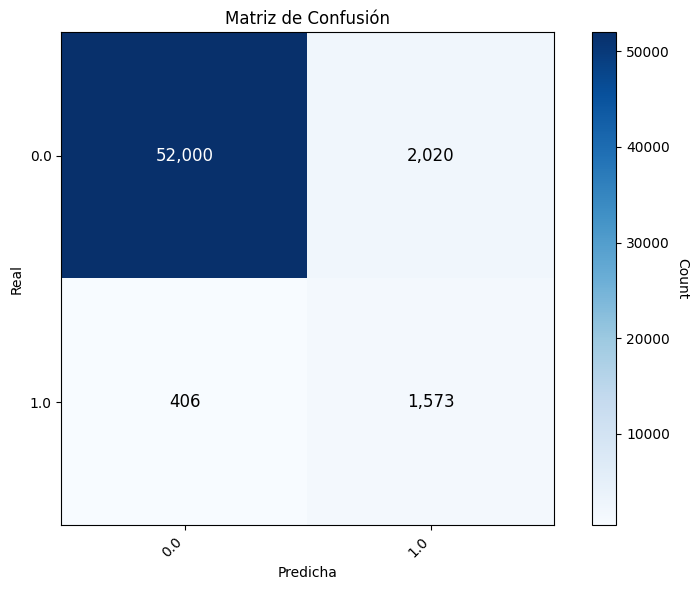


Reporte de Clasificación:


,Clase,precision,recall,f1-score,support
0,0.0,0.9923,0.9626,0.9772,54020
1,1.0,0.4378,0.7948,0.5646,1979
2,accuracy,,,0.9567,55999
3,macro avg,0.715,0.8787,0.7709,55999
4,weighted avg,0.9727,0.9567,0.9626,55999


In [16]:
# -------------------------
# Selección final: escoger el modelo con mayor recall de la clase minoritaria en validación
# -------------------------
best_overall = max(results, key=lambda r: r['val_recall'] if r['val_recall'] is not None else 0.0)
print("Resumen de resultados (val recall):")
for r in results:
    print("-"*170)
    print(f"{r['estimator_name']}: recall_val = {r['val_recall']:.4f}, best_params = {r['best_params']}")

print(f"\nMejor modelo seleccionado: {best_overall['estimator_name']} con recall={best_overall['val_recall']:.4f}")

# -------------------------
# Evaluar el mejor modelo sobre el conjunto de test (métricas finales)
# -------------------------
best_model_pipeline = best_overall['model']
pred_test = best_model_pipeline.transform(test_pp)
final_recall = compute_recall_minority(pred_test)
final_pr = evaluator_pr.evaluate(pred_test)

print(f"Performance final sobre TEST: recall_minority = {final_recall:.4f}, areaUnderPR = {final_pr:.4f}")

# Persistir el modelo seleccionado
output_model_path = os.path.join(os.getcwd(), 'best_callcenter_model')
best_model_pipeline.write().overwrite().save(output_model_path)
print(f"Modelo guardado en: {output_model_path}")

# pred_df: resultado de best_model.transform(test_pp) con columnas 'label' y 'prediction'
report_dict, df_report, cm_df = report_and_pretty_confusion_matrix(pred_df=pred_test, label_col='label', pred_col='prediction')

# Mostrar reporte de clasificación estilizado
print("\nReporte de Clasificación:")
display(df_report)   # en Jupyter

Como era de esperarse, utilizar la técnica de pesos de clase para fijar la atención en la clase minoritaria aumentó el recall de converted = Yes reduciéndose los falsos negativos en detrimento de un aumento de falsos positivos. A pesar de ello se ha conseguido un modelo que identifica correctamente alrededor del 80% de las llamadas que realmente son contestadas. Por supuesto ambos errores mencionados tienen un costo pero se asumen en un caso de uso donde se prefiere no perder un votante y gastar recursos de más llamando votantes que no contestarán. Al menos en el segundo caso se pierden tiempo y recursos que no resultan tan valiosos como el contacto humano con un votante.  



# Análisis prescriptivo

Esta es la fase final del proceso típico de Business Analytics. Mientras el análisis descriptivo responde a la pregunta: ¿qué va a pasar? (¿el  votante contestará?), el análisis prescriptivo en un nivel de complejidad mayor resuelve el interrogante crucial: ¿Qué debe hacerse o cómo proceder para que el objetivo suceda? (¿Qué día llamar a un votante determinado, en cuál franja horaria, con cuál estrategia y operador, tal que se maximice la probabilidad de contestación?). Esta fase final tiene como objetivo utilizar el modelo entrenado para determinar el set de valores del conjunto de variables libres ("day_of_the_week", "time_slot", "operator_name", "strategy_dial") que maximiza la probabilidad de contestación por parte de cierto votante cuyos atributos asociados instancian el set de variables fijas. 

In [ ]:
# -------------------------
# Importaci[on de librerias necesarias
# -------------------------
import itertools
import random
import pandas as pd
from pyspark.sql import functions as F
from pyspark.sql.types import StringType, DoubleType
from pyspark.ml.linalg import VectorUDT
from pyspark.ml.functions import vector_to_array

In [ ]:
# -------------------------
# Parametros de sintonización
# -------------------------
FREE_VARS = ["day_of_the_week", "time_slot", "operator_name", "strategy_dial"]
FIXED_VARS = ["age_range", "city", "candidate_name"] 
JOIN_KEY = "voter_id"
SEED = 42

# El conjunto resultante del producto cartesiano entre los valores posibles de las variables libres tiene un tamaño L
# Se seleccionan máximo 5000 elementos aleatorios de dicho conjunto
max_combinations = 5000
# Se seleccionan las sprimeras 5 mejores combinaciones
top_k = 5

In [17]:
# -------------------------
# Creación de funciones necesarias
# -------------------------

# Obtención de diccionario con valores únicos de cada variable libre. Se obtiene sobre el dataset completo de llamadas combinado con Dim Votantes
def get_unique_values_for_free_vars(df, free_vars, per_col_limit=5000):
    vals = {}
    for c in free_vars:
        # take distinct non-null values from df for column c
        distinct_rows = df.select(c).distinct().filter(F.col(c).isNotNull()).limit(per_col_limit).collect()
        vals[c] = [r[c] for r in distinct_rows]
    return vals

# Obtención de lista de 4-tuplas con las max_combinations combinaciones de valores de variables libres
def generate_candidate_combinations(values_lists, max_combinations=5000, seed=42):
    sizes = [len(v) for v in values_lists]
    total = 1
    for s in sizes:
        total *= max(1, s)
    # If total is small, enumerate all
    # Si el tamaño del conjunto del producto cartesiano es menor al límite impuesto de combinaciones, se retorna el producto cartesiano completo
    if total <= max_combinations:
        return list(itertools.product(*values_lists))
    # En caso contrario, limitar el conjunto del producto cartesiano al máximo de combinaciones impuesto
    random.seed(seed)
    combos_set = set()
    attempts = 0
    max_attempts = max_combinations * 20  # safety cap
    while len(combos_set) < max_combinations and attempts < max_attempts:
        choice = tuple(random.choice(v) for v in values_lists)
        combos_set.add(choice)
        attempts += 1
    return list(combos_set)


# Función principal: Deduce del set de combinaciones de valores de variables libres, aquellas que maximizan la probabilidad de contestación    
def optimize_treatments_for_sample(df, preproc_model, best_model,
                                   free_vars=FREE_VARS, fixed_vars=FIXED_VARS, join_key=JOIN_KEY,
                                   sample_size=5, top_k=5, max_combinations=5000, seed=SEED):
    """
    df: Dataframe combinación de las tablas Delta Fct Llamadas y Dim Votantes
    preproc_model: Pipeline ajustado de codificación numérica
    best_model: Mejor modelo luego de hacer búsqueda aleatoria de hiperparámetros con validación cruzada
    Retorno: Dataframe de pandas con el top k-ésimo de estrategias por votante con el score respectivo de probabilidad de contestación
    """
    # Obtención de Spark Dataframe con los sample_size votantes seleccionados aleatoriamente y variables fijas únicamente
    voters_rows = (voters_sel # Se extraen los votantes de la tabla Delta de votantes reducida con las variables fijas
                     .sample(False, 0.01, seed) 
                     .limit(sample_size)
                     .collect())
    if len(voters_rows) == 0:
        raise ValueError("No hay votantes disponibles en la tabla delta de votantes para muestrear. Revisar contenido de tabla Delta")

    # Obtener valores únicos de df combinados por variable libre 
    free_values_dict = get_unique_values_for_free_vars(df, free_vars)
    values_lists = [free_values_dict[c] for c in free_vars]

    # Generar lista de 4-tuplas con un límite de combinaciones de max_combinations
    combos = generate_candidate_combinations(values_lists, max_combinations=max_combinations, seed=seed)
    if len(combos) == 0:
        raise ValueError("No se generó ninguna combinación de variables libreas. Revisar los valores distintos de las variables libres.")

    results_rows = []

    # Creación de Spark Dataframe con todas las combinaciones de valores de variables libres por votante
    for voter in voters_rows:
        voter_id = voter[join_key]
        fixed_values = {c: voter[c] for c in fixed_vars}
        # Construcción de filas candidatas como lista de diccionarios
        # Cada diccionario contiene las variables fijas del votante junto con una de las posibles max_combinations como valores de las variables libres. Se incluye código de votante
        candidate_dicts = []
        for comb in combos:
            row = dict(zip(free_vars, comb))
            # Inlcuir atributos fijos
            row.update(fixed_values)
            # Mantener traza para rastreo
            row[join_key] = voter_id
            candidate_dicts.append(row)

        # Creación de Spark Dataframe de combinaciones candidatas
        import pandas as pd
        pdf = pd.DataFrame(candidate_dicts)
        cand_sdf = spark.createDataFrame(pdf)   
        
        # Transformar dataframe a través del pipeline de preprocesamiento o de codificación numérica para crear "features" 
        cand_pp = preproc_model.transform(cand_sdf)

        # El dataframe codificado es proporcionado al mejor modelo que espera el campo features para generar la predicción de contestación
        pred = best_model.transform(cand_pp)

        # Obtención de Spark Dataframe con campo score conteniendo los resultado de predicción para cada combinación de valores de variables libres
        try:
            if 'probability' in pred.columns:
                scored = pred.withColumn('score', vector_to_array(F.col('probability')).getItem(1).cast(DoubleType()))
            elif 'rawPrediction' in pred.columns:
                scored = pred.withColumn('score', vector_to_array(F.col('rawPrediction')).getItem(1).cast(DoubleType()))
            elif 'prediction' in pred.columns:
                scored = pred.withColumn('score', F.col('prediction').cast(DoubleType()))
            else:
                raise RuntimeError("Salida de mejor modelo no contiene ninguna columna de resultado de predicción para obtener score")
        except Exception as e:
            # Fallback para versiones de Spark que no soportan vector_to_array, usando un UDF que extrae el componente positivo
            # El Vector DenseVector/SparseVector en PySpark se comporta como una secuencia en Python (indexada) por lo que hacer v[1] es correcto
            def _extract_pos_from_vector(v):
                if v is None:
                    return None
                try:
                    # si v es Vector (Dense/Sparse) o lista/tuple
                    # en algunos modelos rawPrediction, v puede ser un escalar por lo que esta posibilidad debe ser considerada
                    if hasattr(v, '__len__'):
                        # si tiene al menos 2 componentes, se devuelve aquella con índice 1 (probabilidad positiva)
                        if len(v) > 1:
                            return float(v[1])
                        else:
                            return float(v[0])
                    else:
                        # valor escalar
                        return float(v)
                except Exception:
                    return None
        
            udf_extract = F.udf(_extract_pos_from_vector, DoubleType())
        
            if 'probability' in pred.columns:
                scored = pred.withColumn('score', udf_extract(F.col('probability')))
            elif 'rawPrediction' in pred.columns:
                scored = pred.withColumn('score', udf_extract(F.col('rawPrediction')))
            elif 'prediction' in pred.columns:
                scored = pred.withColumn('score', F.col('prediction').cast(DoubleType()))
            else:
                raise RuntimeError("Model output does not contain probability/rawPrediction/prediction columns to compute a score.") from e

        # Selección de las k primeras filas de scored con los valores más altos de probabilidad de contestación
        topk_df = (scored.select(join_key, *fixed_vars, *free_vars, 'score')
                         .orderBy(F.col('score').desc())
                         .limit(top_k))

        # Convertir mejores k combinaciones a objeto Dataframe de pandas 
        topk_pd = topk_df.toPandas()
        # Recolección de las mejores combinaciones junto al código de votante y los valores de sus variables fijas
        results_rows.append((voter_id, fixed_values, topk_pd))

    # Construcción de dataframe final con las mejores combinaciones de valores de atributos para todos los sample_size votantes seleccionados al azar
    summary_list = []
    for voter_id, fixed_vals, df_topk in results_rows:
        for _, r in df_topk.iterrows():
            row = {'voter_id': voter_id}
            row.update({f'fixed__{k}': fixed_vals[k] for k in fixed_vals})
            for f in free_vars:
                row[f] = r[f]
            row['score'] = float(r['score'])
            summary_list.append(row)

    summary_df = pd.DataFrame(summary_list)
    return summary_df

# -------------------------
# Ejecución de algoritmo completo de obtención de top_k mejores combinaciones de valores de variables fijas para los sample_size votantes seleccionados aleatoriamente
# -------------------------
summary = optimize_treatments_for_sample(df=df,
                                         preproc_model=preproc_model,
                                         best_model=best_overall['model'] if isinstance(best_overall, dict) else best_model,
                                         free_vars=FREE_VARS,
                                         fixed_vars=FIXED_VARS,
                                         join_key=JOIN_KEY,
                                         sample_size=1,
                                         top_k=top_k,
                                         max_combinations=max_combinations,
                                         seed=SEED)

# Mostrar dataframe resultante
print("Top 5 de principales estrategias de llamada por cada votante sampleado")
display(summary)  
# Opcionalmente, se persiste el dataframe resultante en disco 
path_output_summary = "top_5_tratamientos_por_voteante.csv"
summary.to_csv(path_output_summary, index=False)
print(f"Resumen almacenado correctamente en el fichero ubicado en {path_output_summary}")

# Finalmente se interrumple la SparkSession
spark.stop()

Top suggested treatments for each sampled voter (higher score = higher predicted turnout probability):


,voter_id,fixed__age_range,fixed__city,fixed__candidate_name,day_of_the_week,time_slot,operator_name,strategy_dial,score
0,6e5cc6bcd9e1fc8c70fa041735d98cd89312602693473e...,YoungAdult,City-IVK,candidate_name_3,Monday,noon,Agent 2,Main,1.0
1,6e5cc6bcd9e1fc8c70fa041735d98cd89312602693473e...,YoungAdult,City-IVK,candidate_name_3,Tuesday,noon,Agent 2,Main,1.0
2,6e5cc6bcd9e1fc8c70fa041735d98cd89312602693473e...,YoungAdult,City-IVK,candidate_name_3,Monday,evening,Agent 2,Main,1.0
3,6e5cc6bcd9e1fc8c70fa041735d98cd89312602693473e...,YoungAdult,City-IVK,candidate_name_3,Tuesday,morning,Agent 2,Main,1.0
4,6e5cc6bcd9e1fc8c70fa041735d98cd89312602693473e...,YoungAdult,City-IVK,candidate_name_3,Saturday,noon,Agent 2,Main,1.0
5,7a378d5280cc78d4b731341d452ac3647c9d58d8869167...,Senior,City-DVK,candidate_name_3,Monday,noon,Agent 2,Main,1.0
6,7a378d5280cc78d4b731341d452ac3647c9d58d8869167...,Senior,City-DVK,candidate_name_3,Tuesday,noon,Agent 2,Main,1.0
7,7a378d5280cc78d4b731341d452ac3647c9d58d8869167...,Senior,City-DVK,candidate_name_3,Monday,evening,Agent 2,Main,1.0
8,7a378d5280cc78d4b731341d452ac3647c9d58d8869167...,Senior,City-DVK,candidate_name_3,Tuesday,morning,Agent 2,Main,1.0
9,7a378d5280cc78d4b731341d452ac3647c9d58d8869167...,Senior,City-DVK,candidate_name_3,Saturday,noon,Agent 2,Main,1.0


Saved summary to top_treatments_per_voter.csv
